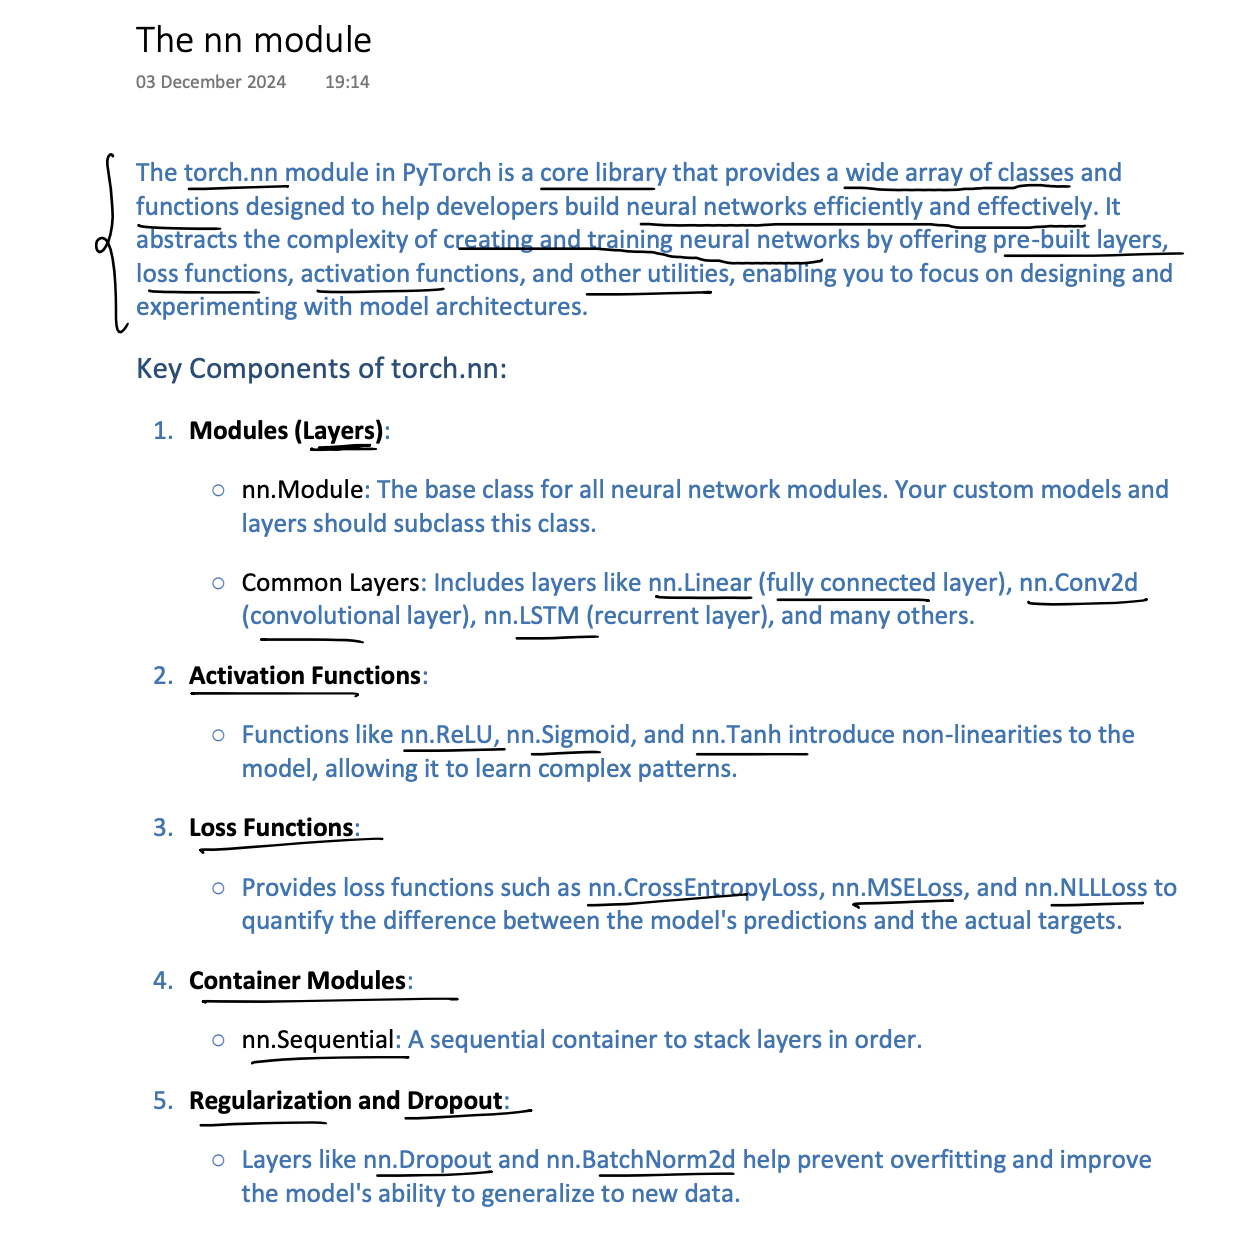

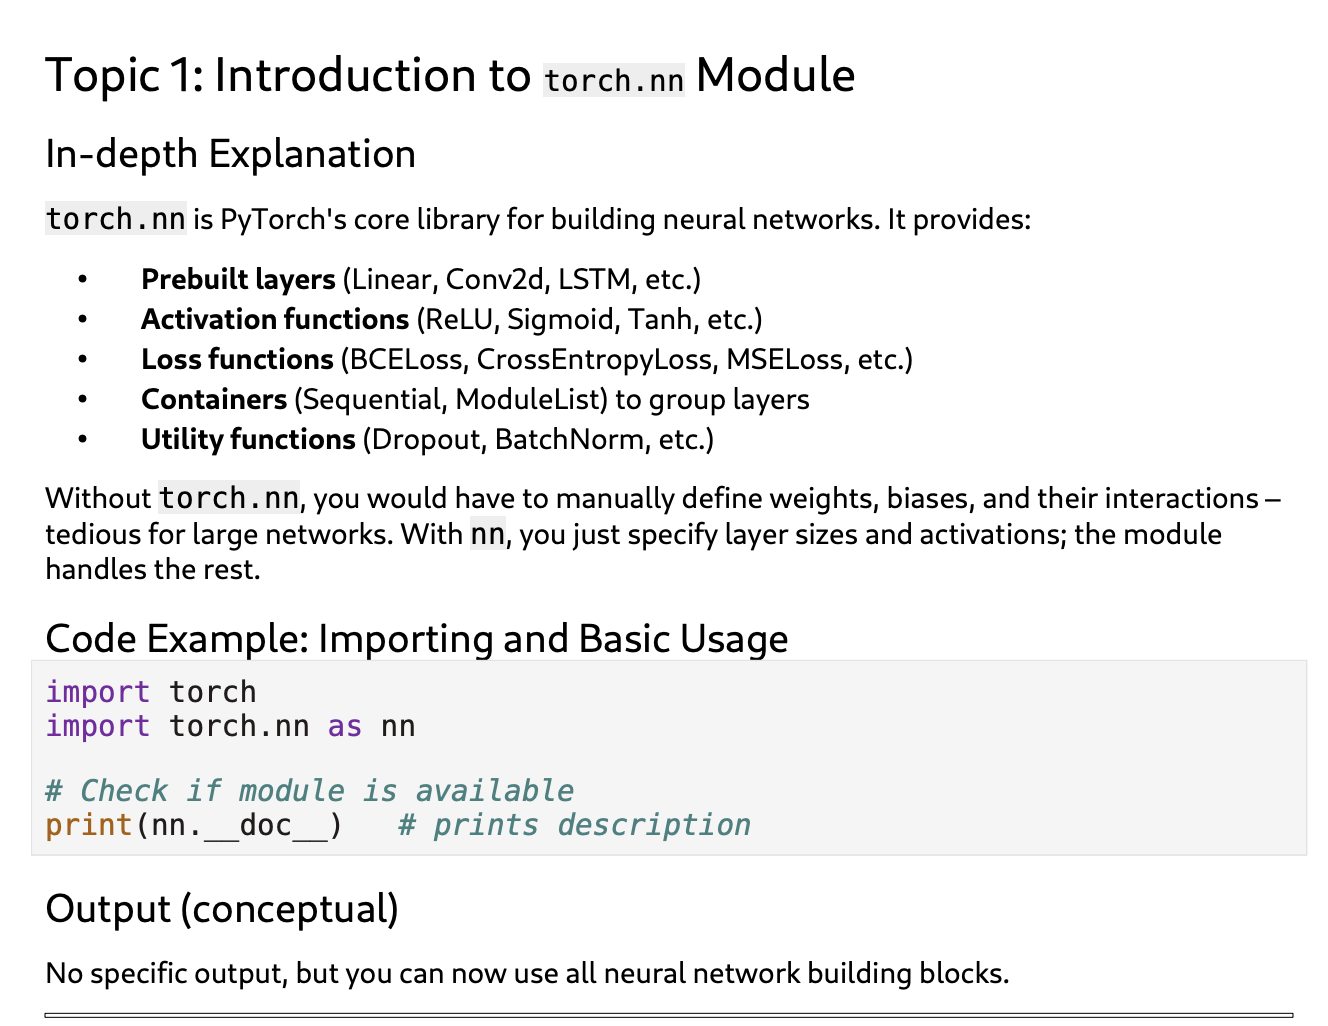

In [1]:
import torch
import torch.nn as nn

#check if module is available
print(nn.__doc__)#print description

None


## Topic 2: Creating a Neural Network with nn.Module (Single Neuron)
In-depth Explanation
- To create a custom model, you inherit from nn.Module. Inside __init__, you define layers as
class attributes. Inside forward, you define how data passes through layers.
Key steps:
1. class MyModel(nn.Module):
2. Call super().__init__() inside __init__ (invokes parent constructor)
3. Define layers: self.linear = nn.Linear(input_size, output_size)
4. Define activation: self.sigmoid = nn.Sigmoid()
5. In forward(self, x): pass x through layers sequentially and return output

Why super().__init__()? It registers all parameters so PyTorch can track gradients and
manage them.

### Code Example: Single Neuron (5 inputs → 1 output with Sigmoid) Forward Pass only (no backward,error calculation and so on) For conceptual Only

In [2]:
#create model class
import torch
import torch.nn as nn

class SingleNeuron(nn.Module):
    def __init__(self,num_features):
        super().__init__() #must call parent constructor
        self.linear=nn.Linear(num_features,1) #Linear layer:Wx+b
        self.sigmoid=nn.Sigmoid() #Activation
    
    def forward(self,x):
        out=self.linear(x) #compute z=Wx+b
        out=self.sigmoid(out) #apply sigmoid
        return out



In [4]:
# Create fake dataset: 10 samples, 5 features each
features=torch.randn(size=(10,5))
print(features.shape)

torch.Size([10, 5])


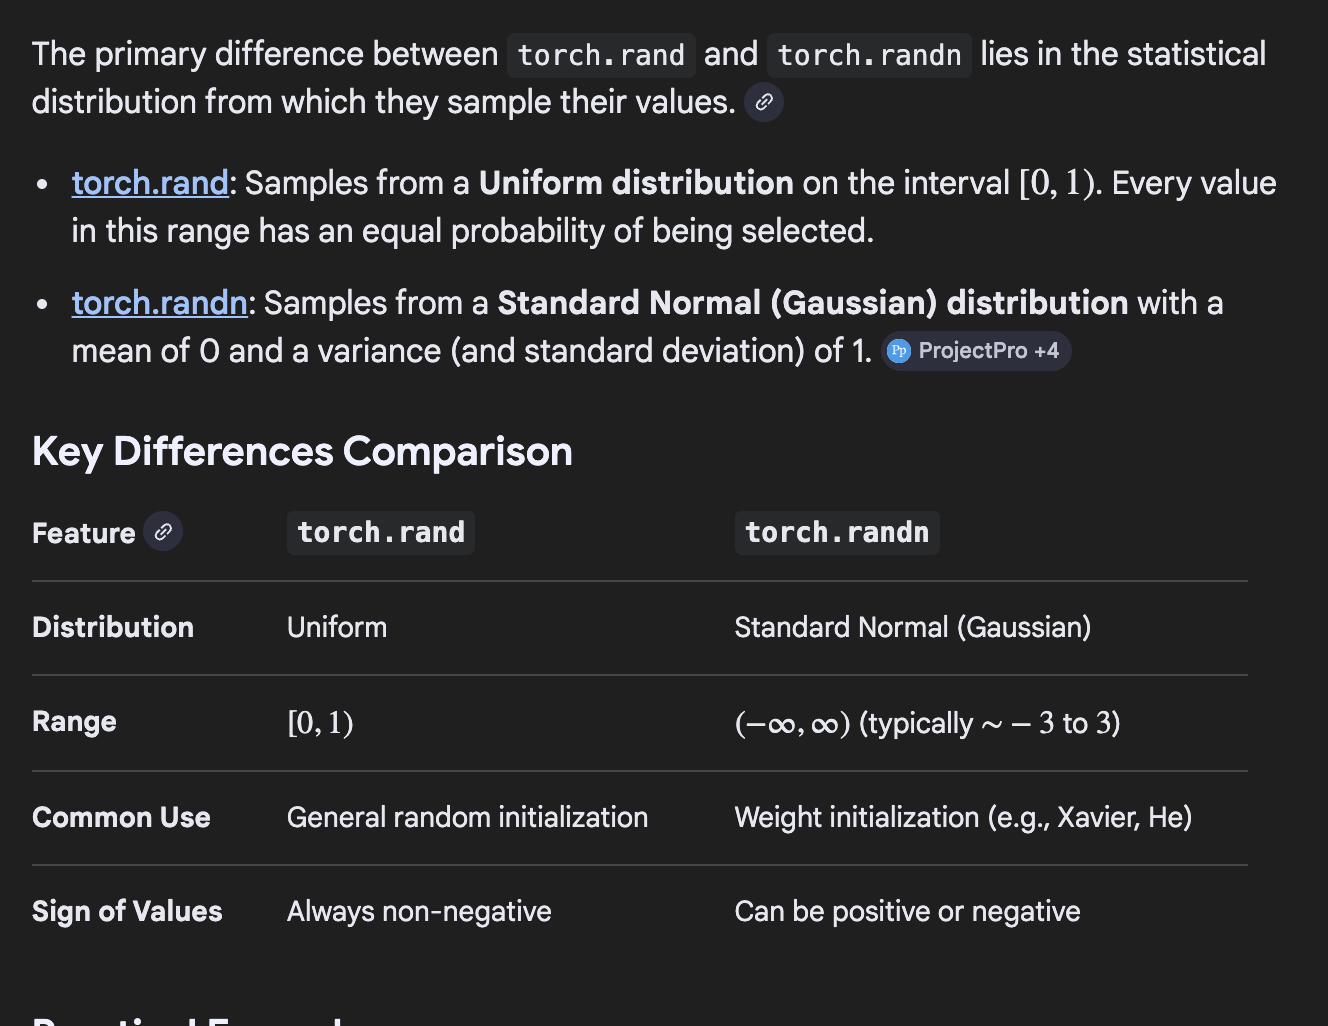

In [6]:
# Instantiate model
model=SingleNeuron(num_features=features.shape[1])

#Forward pass
output=model(features) #Note:Call model directly ,not model.forward(features) though this works ,the model(features) is recommended by pytorch,they somehow have made this __call__ feature trigger forward class if called model .
print("Output shape: ",output.shape)
print("Output: ",output)

Output shape:  torch.Size([10, 1])
Output:  tensor([[0.5984],
        [0.5000],
        [0.2765],
        [0.5218],
        [0.1058],
        [0.5236],
        [0.6117],
        [0.3312],
        [0.3006],
        [0.3267]], grad_fn=<SigmoidBackward0>)


#### Each of the 10 samples gives a single probability value (between 0 and 1).

#### Inspecting Parameters

In [ ]:
#View weights (shape:1*5) 5 features as weights
print("Weights: ",model.linear.weight)

#View bias (shape:1)
print("Bias: ",model.linear.bias)

Weights:  Parameter containing:
tensor([[ 0.1922,  0.3394,  0.1058, -0.1929, -0.3834]], requires_grad=True)
Bias:  Parameter containing:
tensor([-0.3281], requires_grad=True)


Total trainable parameters = 5 weights + 1 bias = 6.

#### Visualizing Network Structure (optional)


In [ ]:
# !pip install torchinfo

In [8]:
from torchinfo import summary

summary(model=model,input_size=(10,5))

Layer (type:depth-idx)                   Output Shape              Param #
SingleNeuron                             [10, 1]                   --
├─Linear: 1-1                            [10, 1]                   6
├─Sigmoid: 1-2                           [10, 1]                   --
Total params: 6
Trainable params: 6
Non-trainable params: 0
Total mult-adds (M): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

## Topic 3: Adding a Hidden Layer (Multi-Layer Network)

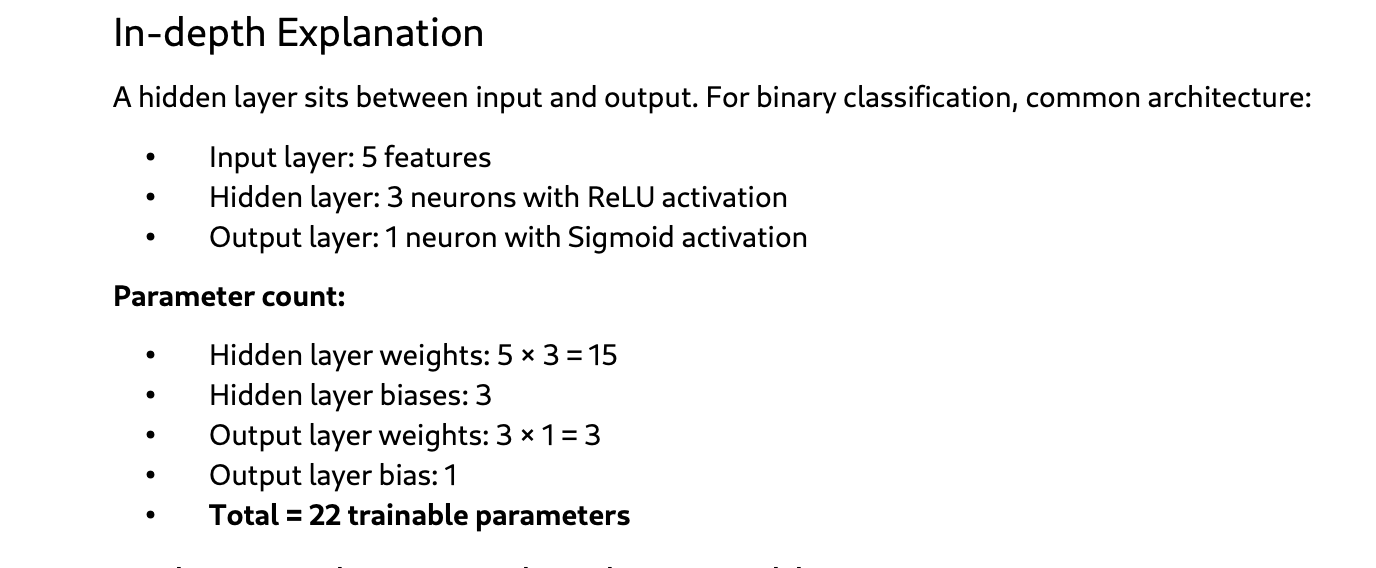

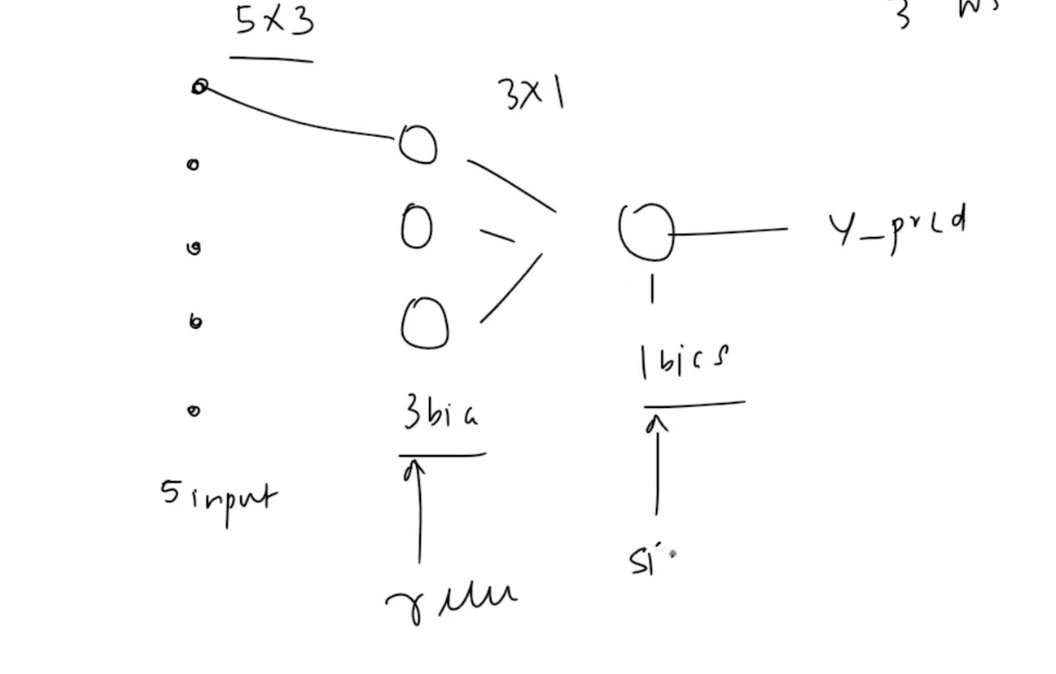

### Code Example: Network with One Hidden Layer

In [9]:
import torch
import torch.nn as nn

In [ ]:
## define class for the model
class TwoLayerNet(nn.Module):
    def __init__(self,num_features):
        super().__init__()
        self.hidden=nn.Linear(num_features,3) #hidden layer:5 ->3, #linear1
        self.relu=nn.ReLU() #activation for hidden
        self.output=nn.Linear(3,1) #output layer :3 ->1,
        #linear2
        self.sigmoid=nn.Sigmoid() #activation for output

    def forward(self,x):  # x->features
        x=self.hidden(x)
        x=self.relu(x)
        x=self.output(x)
        x=self.sigmoid(x)
        return x

In [ ]:
# Create fake dataset: 10 samples, 5 features each
features=torch.randn(size=(10,5))

# Instantiate the model
model=TwoLayerNet(num_features=features.shape[1])

#call model for forward pass
#model.forward(features)
output=model(features) #features shape:(10,5)

print("Output shape: ",output.shape)
print("Output: ",output)

Output shape:  torch.Size([10, 1])
Output:  tensor([[0.6038],
        [0.5991],
        [0.5971],
        [0.5973],
        [0.5964],
        [0.5738],
        [0.5833],
        [0.5924],
        [0.5698],
        [0.5925]], grad_fn=<SigmoidBackward0>)


#### Inspecting models

In [16]:
#View weights
print("Weights: ",model.hidden.weight)
print("Weights: ",model.output.weight)
#View bias
print("Bias: ",model.hidden.bias)
print("Bias: ",model.output.bias)

Weights:  Parameter containing:
tensor([[-0.2240,  0.2446, -0.1428,  0.2741, -0.4096],
        [ 0.0714,  0.4441, -0.1435, -0.0522,  0.3724],
        [-0.1490, -0.4289, -0.3528, -0.0837,  0.2423]], requires_grad=True)
Weights:  Parameter containing:
tensor([[-0.2212,  0.1271,  0.0617]], requires_grad=True)
Bias:  Parameter containing:
tensor([ 0.2029,  0.0287, -0.4337], requires_grad=True)
Bias:  Parameter containing:
tensor([0.3346], requires_grad=True)


#### Visualizing Network Structure (optional)


In [17]:
from torchinfo import summary

summary(model=model,input_size=(10,5))

Layer (type:depth-idx)                   Output Shape              Param #
TwoLayerNet                              [10, 1]                   --
├─Linear: 1-1                            [10, 3]                   18
├─ReLU: 1-2                              [10, 3]                   --
├─Linear: 1-3                            [10, 1]                   4
├─Sigmoid: 1-4                           [10, 1]                   --
Total params: 22
Trainable params: 22
Non-trainable params: 0
Total mult-adds (M): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

## Topic 4: Using nn.Sequential Container

Writing **forward** manually becomes cumbersome for deep networks. **nn.Sequential** is a
container that automatically chains layers. You pass layers in order, and forward calls them
sequentially.
Benefits:
- Less boilerplate code
- Easy to read architecture
- Still inherits from nn.Module

#### Code Example: Same Two-Layer Net with Sequential

In [19]:
import torch
import torch.nn as nn
# define class model

class TwoLayerNetSequential(nn.Module):
    def __init__(self,num_features):
        super().__init__()
        self.network=nn.Sequential(
            nn.Linear(num_features,3),
            nn.ReLU(),
            nn.Linear(3,1),
            nn.Sigmoid()
        )
    
    def forward(self,x): # x -> features
        x= self.network(x)
        return x #just one line !


In [20]:
# Create fake dataset: 10 samples, 5 features each
features=torch.randn(size=(10,5))

# Instantiate the model
model=TwoLayerNetSequential(num_features=features.shape[1])

#call model for forward pass
#model.forward(features)
output=model(features) #features shape:(10,5)

print("Output shape: ",output.shape)
print("Output: ",output)

Output shape:  torch.Size([10, 1])
Output:  tensor([[0.4547],
        [0.5070],
        [0.3449],
        [0.5475],
        [0.5151],
        [0.5599],
        [0.4739],
        [0.5599],
        [0.4914],
        [0.2083]], grad_fn=<SigmoidBackward0>)


## Topic 5: Using Built-in Loss Function (BCELoss)

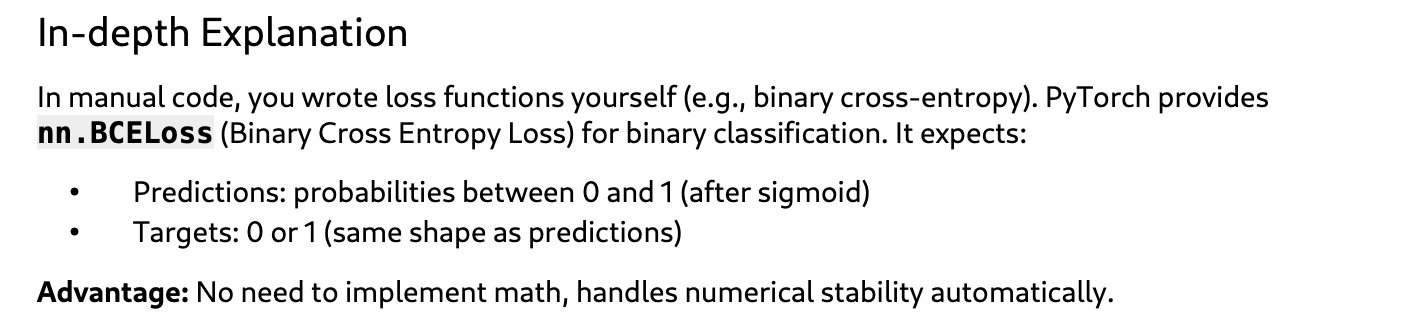

#### Code Example: Replacing Manual Loss with BCELoss

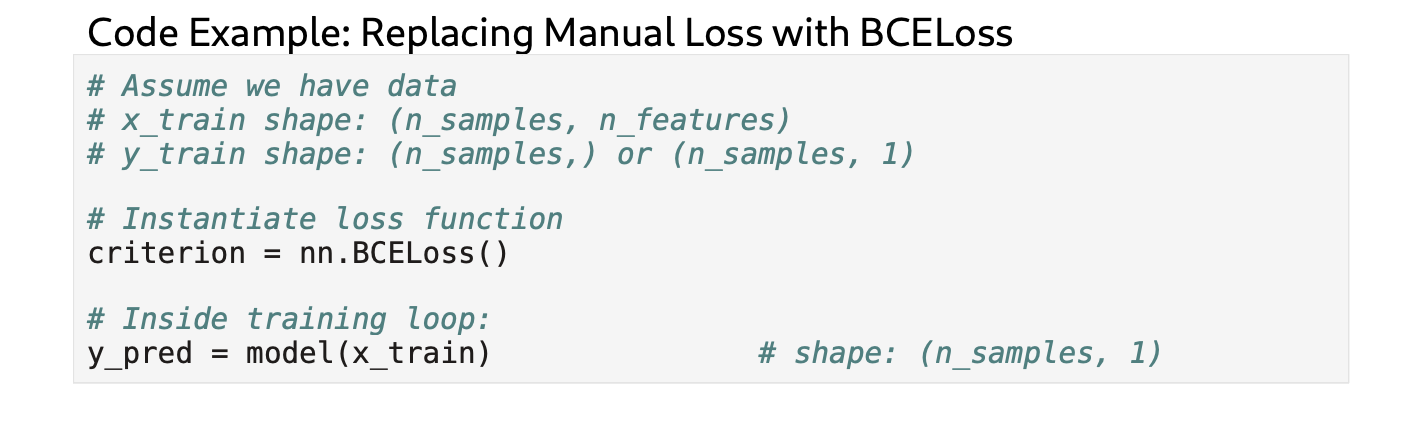

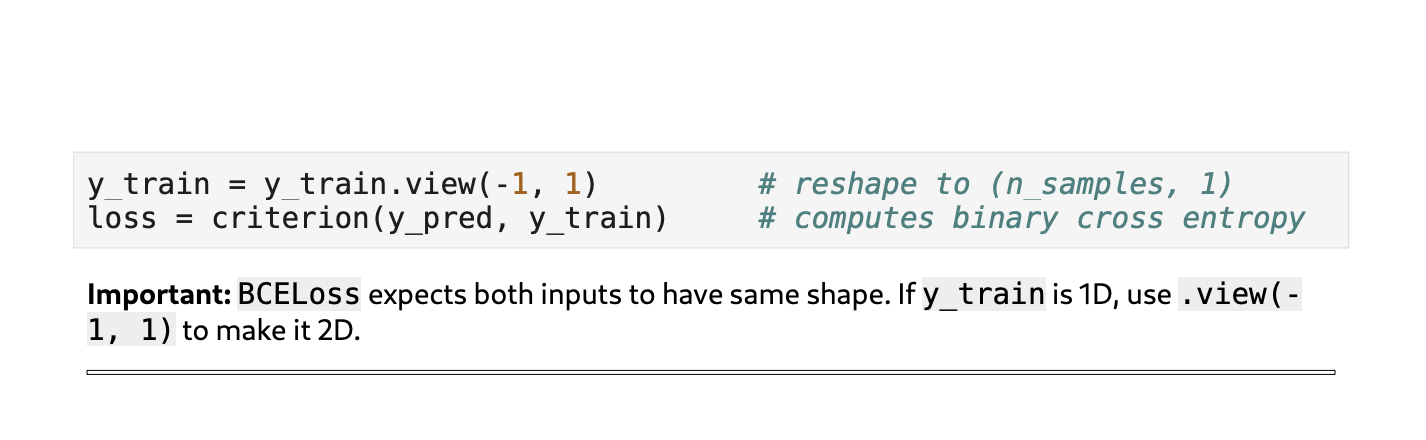

## Topic 6: Using Built-in Optimizer (torch.optim)

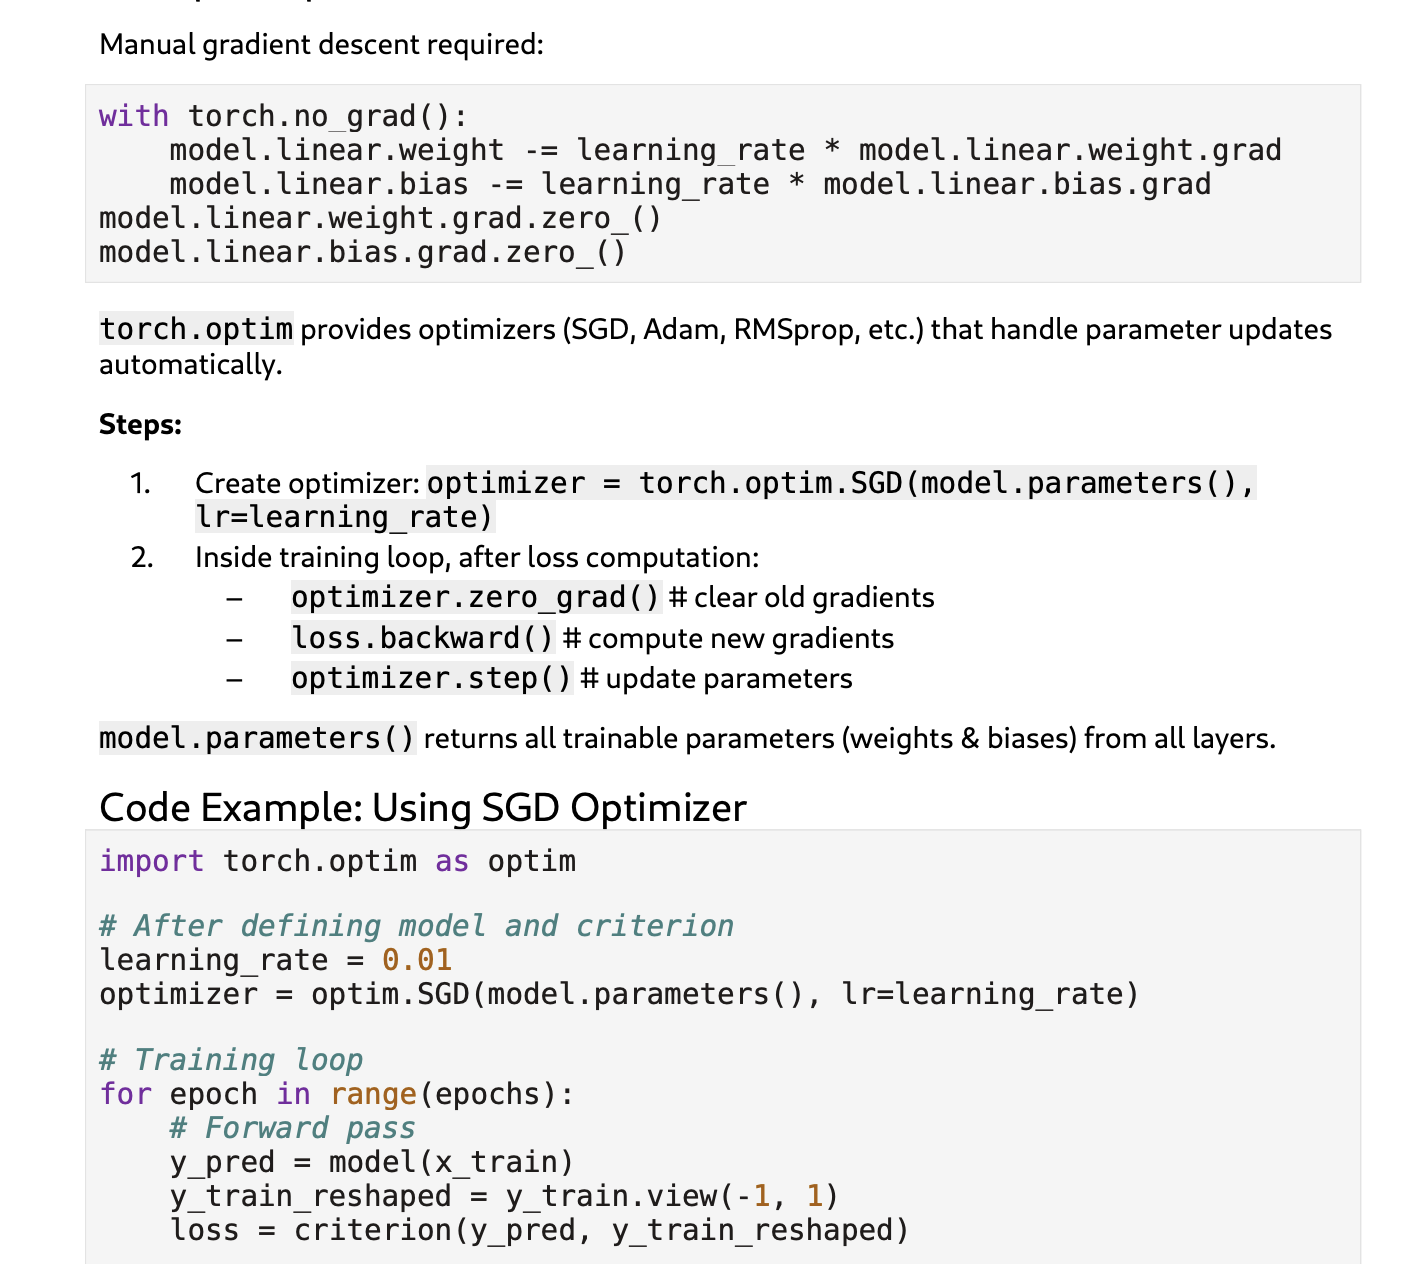

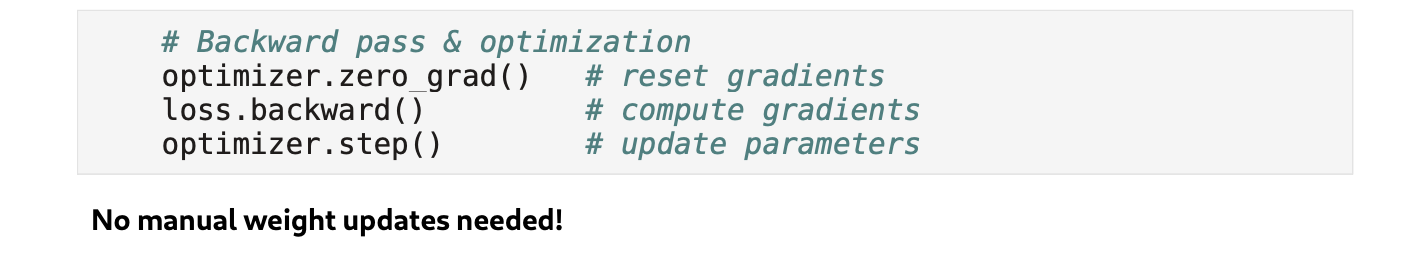

## Complete Improved Training Pipeline (All Four Improvements)

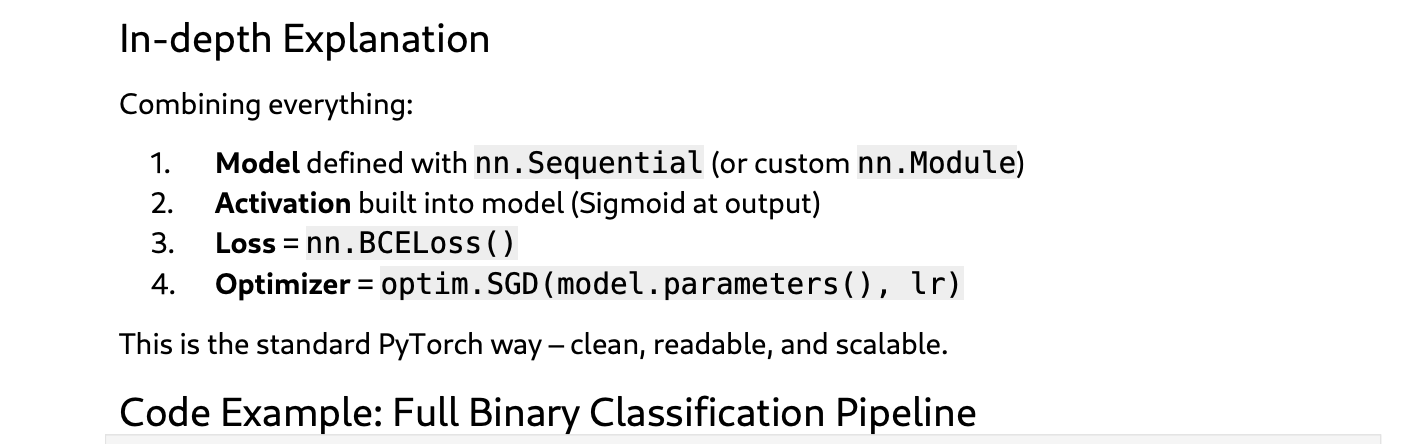

### Dont run this code (just for complete pipeline example)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
# ---------- 1. Load & preprocess data (example) ----------
# Assume x_train, y_train are already tensors
# x_train shape: (n_samples, n_features)
# y_train shape: (n_samples,) with values 0/1
n_features = x_train.shape[1]
# ---------- 2. Define Model ----------
model = nn.Sequential(
 nn.Linear(n_features, 3),
 nn.ReLU(),
 nn.Linear(3, 1),
 nn.Sigmoid()
)
# ---------- 3. Define Loss ----------
criterion = nn.BCELoss()
# ---------- 4. Define Optimizer ----------
learning_rate = 0.01
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
# ---------- 5. Training Loop ----------
epochs = 100
for epoch in range(epochs):
 # Forward pass
 y_pred = model(x_train)
 y_train_reshaped = y_train.view(-1, 1) # ensure same shape
 loss = criterion(y_pred, y_train_reshaped)

 # Backward pass & optimization
 optimizer.zero_grad()
 loss.backward()
 optimizer.step()

 # Optional: print loss every 10 epochs
 if (epoch+1) % 10 == 0:
 print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")
# ---------- 6. Evaluation ----------
with torch.no_grad():
 y_pred_final = model(x_train)
 predicted = (y_pred_final > 0.5).float()
 accuracy = (predicted.view(-1) == y_train).float().mean()
 print(f"Accuracy: {accuracy.item():.4f}")


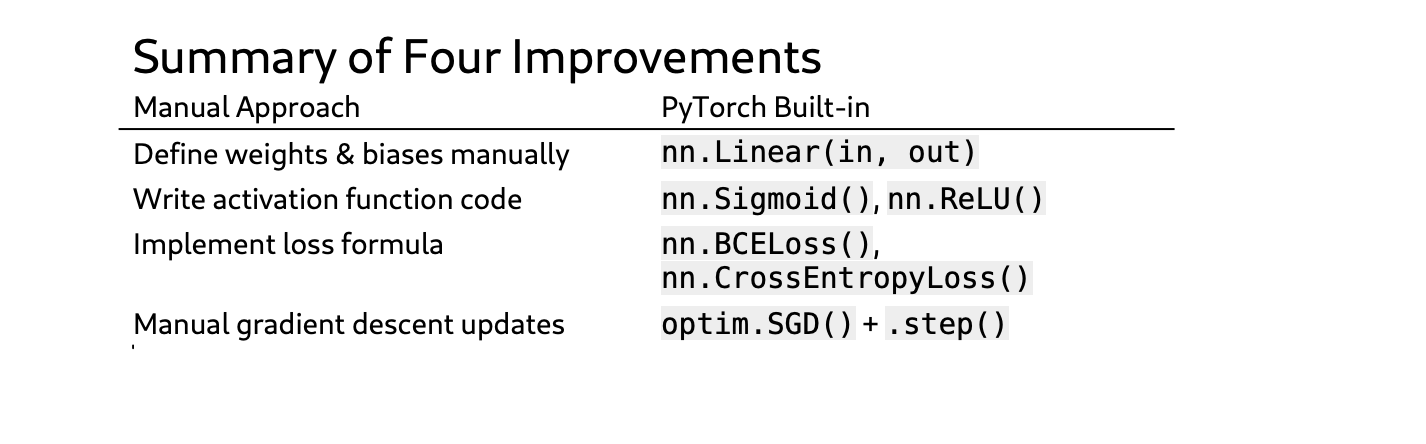